# Heston Stochastic-Volatility Option Pricing via ADI Crank-Nicolson (Douglas Scheme)

## Problem

Price a European call option `U(S,v,t)` under the Heston (1993) stochastic-volatility model

```
dS = r S dt + sqrt(v) S dW1
dv = kappa(theta - v) dt + sigma sqrt(v) dW2
corr(dW1, dW2) = rho
```

which gives the two-dimensional pricing PDE

```
dU/dt + (1/2) v S^2 d2U/dS2 + rho sigma v S d2U/dSdv + (1/2) sigma^2 v d2U/dv2
      + r S dU/dS + kappa(theta - v) dU/dv - r U = 0
```

with terminal payoff `U(S,v,T) = max(S-K, 0)`. Unlike Black-Scholes, this PDE has two spatial
dimensions (`S` and `v`) plus a cross-derivative term, so a direct (non-directional) implicit
scheme would require solving a dense 2D linear system at every time step.

## Method

**Reference price.** As an independent ground truth, the semi-analytical Heston price is computed
via its characteristic function (Little Trap formulation of Albrecher et al., 2007) and numerical
Fourier inversion:

```
C = S0*P1 - K*exp(-rT)*P2,   Pj = 1/2 + (1/pi) * Integral_0^inf Re[ exp(-i*u*ln K) * phi_j(u) / (i*u) ] du
```

This is checked against the closed-form Black-Scholes price in the limit `sigma -> 0`, `rho = 0`,
`theta = v0` (deterministic variance), where the two must agree exactly.

**PDE solver.** The spatial operator is split as `A = A0 + A1 + A2`: `A0` is the mixed
`d2U/dSdv` term, `A1` is the S-direction operator (`S`-diffusion, `S`-drift, half the discount),
`A2` is the v-direction operator (`v`-diffusion, mean-reverting `v`-drift, half the discount).
Time-stepping uses the **Douglas ADI scheme** (theta = 1/2, a directional Crank-Nicolson), reference:
in 't Hout, K.J. & Foulon, S. (2010), *ADI finite difference schemes for option pricing in the
Heston model with correlation*, Int. J. Numer. Anal. Model., 7(2), 303-320 (parameter Set 1 used
below). Each time step:

```
Y0 = U^n + dt * A(U^n)                         (explicit predictor, full operator)
(I - theta*dt*A1) Y1 = Y0 - theta*dt*A1(U^n)   (implicit correction, S-direction, tridiagonal per v-row)
(I - theta*dt*A2) Y2 = Y1 - theta*dt*A2(U^n)   (implicit correction, v-direction, tridiagonal per S-column)
U^{n+1} = Y2
```

Both implicit sub-steps are tridiagonal (`scipy.linalg.solve_banded`) since each is implicit in
only one direction. Uniform grids are used in both `S` and `v` for implementation simplicity and
robustness (a non-uniform grid concentrated near `S=K` and `v=0`, as in the reference paper, would
reach the same accuracy with fewer nodes, at the cost of a more involved non-uniform stencil).

**Boundary conditions.** `U(0,v,t)=0`; `U(S_max,v,t) = S_max - K*exp(-r(T-t))`; `U(S,v_max,t) = S`
(the standard large-`v` approximation); at `v=0` the PDE degenerates (all `v`-scaled terms vanish),
so a one-sided forward difference in `v` is used there instead of dropping the boundary.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded
from scipy.integrate import quad
from scipy.stats import norm

# Parameters (in 't Hout & Foulon 2010, Set 1) -- edit these to price a different contract
kappa = 2.0     # mean-reversion speed of variance
theta_v = 0.04  # long-run variance
sigma = 0.3     # volatility of variance
rho = -0.5      # correlation between asset and variance Brownian motions
r = 0.03        # risk-free rate
T = 1.0         # maturity
K = 100.0       # strike
S0 = 100.0      # spot
v0 = 0.04       # initial variance

In [2]:
def heston_call_price(S0, K, T, r, kappa, theta, sigma, rho, v0):
    # Semi-analytical Heston call price via characteristic-function Fourier inversion
    # (Little Trap formulation, Albrecher et al. 2007).
    def char_func(u, j):
        if j == 1:
            b, u_ = kappa - rho*sigma, 0.5
        else:
            b, u_ = kappa, -0.5
        a = kappa*theta
        x = np.log(S0)
        d = np.sqrt((rho*sigma*1j*u - b)**2 - sigma**2*(2*u_*1j*u - u**2))
        g = (b - rho*sigma*1j*u + d) / (b - rho*sigma*1j*u - d)
        c = 1.0/g
        D = (b - rho*sigma*1j*u - d)/sigma**2 * ((1 - np.exp(-d*T))/(1 - c*np.exp(-d*T)))
        G = (1 - c*np.exp(-d*T))/(1 - c)
        C = r*1j*u*T + a/sigma**2 * ((b - rho*sigma*1j*u - d)*T - 2*np.log(G))
        return np.exp(C + D*v0 + 1j*u*x)

    def integrand(u, j):
        return (np.exp(-1j*u*np.log(K)) * char_func(u, j) / (1j*u)).real

    P1 = 0.5 + (1/np.pi) * quad(integrand, 1e-8, 200, args=(1,), limit=200)[0]
    P2 = 0.5 + (1/np.pi) * quad(integrand, 1e-8, 200, args=(2,), limit=200)[0]
    return S0*P1 - K*np.exp(-r*T)*P2


def bs_call(S0, K, T, r, sigma):
    d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S0*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)


# Sanity check: as sigma (vol-of-vol) -> 0 with rho=0 and theta=v0, variance is
# deterministic and the Heston price must converge to the Black-Scholes price.
bs_ref = bs_call(S0, K, T, r, np.sqrt(v0))
for sig in [0.3, 0.01, 1e-5]:
    p = heston_call_price(S0, K, T, r, kappa, v0, sig, 0.0, v0)
    print(f"vol-of-vol={sig:<8} Heston price={p:.6f}")
print(f"Black-Scholes reference (sigma={np.sqrt(v0):.2f}): {bs_ref:.6f}")

ref_price = heston_call_price(S0, K, T, r, kappa, theta_v, sigma, rho, v0)
print(f"Semi-analytical Heston price (Set 1 parameters): {ref_price:.6f}")

vol-of-vol=0.3      Heston price=9.223633
vol-of-vol=0.01     Heston price=9.413176
vol-of-vol=1e-05    Heston price=9.413403
Black-Scholes reference (sigma=0.20): 9.413403
Semi-analytical Heston price (Set 1 parameters): 9.245034


In [3]:
def _thomas_batch(lower, diag, upper, rhs):
    """
    Vectorized Thomas algorithm for a batch of independent tridiagonal systems, solved in
    parallel across the batch dimension via NumPy array ops instead of one `solve_banded`
    call per system. `lower`, `diag`, `upper`, `rhs` all have shape (batch, n); `lower[:, 0]`
    and `upper[:, -1]` are unused (no left/right neighbor at the boundary rows). Returns `x`
    of shape (batch, n). Same O(n) forward/backward sweep as scipy's banded solver -- this
    changes constant-factor overhead (one NumPy pass over the whole batch per grid index,
    instead of `batch` separate LAPACK dispatches each of size `n`), not asymptotic complexity.
    """
    batch, n = diag.shape
    cp = np.empty((batch, n))
    dp = np.empty((batch, n))
    cp[:, 0] = upper[:, 0] / diag[:, 0]
    dp[:, 0] = rhs[:, 0] / diag[:, 0]
    for i in range(1, n):
        m = diag[:, i] - lower[:, i] * cp[:, i - 1]
        cp[:, i] = upper[:, i] / m
        dp[:, i] = (rhs[:, i] - lower[:, i] * dp[:, i - 1]) / m
    x = np.empty((batch, n))
    x[:, -1] = dp[:, -1]
    for i in range(n - 2, -1, -1):
        x[:, i] = dp[:, i] - cp[:, i] * x[:, i + 1]
    return x


def heston_adi_price(kappa, theta, sigma, rho, r, T, K, S0, v0,
                      Smax, vmax, M, N, num_steps, theta_adi=0.5):
    """Douglas ADI scheme (directional Crank-Nicolson) for the Heston PDE on a uniform (S,v) grid."""
    dS, dv, dt = Smax/M, vmax/N, T/num_steps
    S = np.linspace(0, Smax, M+1)
    v = np.linspace(0, vmax, N+1)
    U = np.maximum(S[:, None] - K, 0.0) * np.ones((M+1, N+1))  # payoff at tau=0
    Sg, Vg = np.meshgrid(S, v, indexing='ij')

    A1_lower = 0.5*Vg*Sg**2/dS**2 - r*Sg/(2*dS)
    A1_diag  = -Vg*Sg**2/dS**2 - 0.5*r
    A1_upper = 0.5*Vg*Sg**2/dS**2 + r*Sg/(2*dS)

    A2_lower = 0.5*sigma**2*Vg/dv**2 - kappa*(theta-Vg)/(2*dv)
    A2_diag  = -sigma**2*Vg/dv**2 - 0.5*r
    A2_upper = 0.5*sigma**2*Vg/dv**2 + kappa*(theta-Vg)/(2*dv)
    A2_lower[:, 0] = 0.0                          # v=0: one-sided forward difference,
    A2_diag[:, 0]  = -kappa*theta/dv - 0.5*r      # no second derivative (its coefficient
    A2_upper[:, 0] = kappa*theta/dv               # vanishes at v=0 anyway)

    def apply_A1(Ua):
        out = np.zeros_like(Ua)
        out[1:-1, :] = (A1_lower[1:-1,:]*Ua[:-2,:] + A1_diag[1:-1,:]*Ua[1:-1,:]
                         + A1_upper[1:-1,:]*Ua[2:,:])
        return out

    def apply_A2(Ua):
        out = np.zeros_like(Ua)
        out[:, 0] = A2_diag[:,0]*Ua[:,0] + A2_upper[:,0]*Ua[:,1]
        out[:, 1:-1] = (A2_lower[:,1:-1]*Ua[:,:-2] + A2_diag[:,1:-1]*Ua[:,1:-1]
                         + A2_upper[:,1:-1]*Ua[:,2:])
        return out

    def apply_A0(Ua):
        out = np.zeros_like(Ua)
        coef = rho*sigma*Vg*Sg
        out[1:-1,1:-1] = coef[1:-1,1:-1]*(Ua[2:,2:]-Ua[2:,:-2]-Ua[:-2,2:]+Ua[:-2,:-2])/(4*dS*dv)
        return out

    # Row/column-independent coefficient arrays for the two implicit half-steps, transposed
    # once outside the time loop (they do not depend on U or on tau, only on the fixed grid).
    diag_j_base  = (1 - theta_adi*dt*A1_diag).T   # shape (N+1, M+1), one row per v-index j
    lower_j_base = (-theta_adi*dt*A1_lower).T
    upper_j_base = (-theta_adi*dt*A1_upper).T

    diag_i_base  = (1 - theta_adi*dt*A2_diag)[1:-1, :]   # shape (M-1, N+1), one row per S-index i
    lower_i_base = (-theta_adi*dt*A2_lower)[1:-1, :]
    upper_i_base = (-theta_adi*dt*A2_upper)[1:-1, :]

    for step in range(num_steps):
        tau_new = (step+1)*dt
        bc_Smax = (Smax - K*np.exp(-r*tau_new)) * np.ones(N+1)

        A_U = apply_A0(U) + apply_A1(U) + apply_A2(U)
        Y0 = U + dt*A_U
        Y0[0, :], Y0[-1, :] = 0.0, bc_Smax

        # Y1: implicit in S. `N+1` independent tridiagonal systems of size `M+1` (one per
        # v-row), solved in a single batched Thomas sweep instead of `N+1` separate
        # `solve_banded` calls.
        rhs1 = (Y0 - theta_adi*dt*apply_A1(U)).T   # (N+1, M+1)
        diag_j, lower_j, upper_j = diag_j_base.copy(), lower_j_base.copy(), upper_j_base.copy()
        diag_j[:, 0], upper_j[:, 0], rhs1[:, 0] = 1.0, 0.0, 0.0            # S=0 Dirichlet: U=0
        diag_j[:, -1], lower_j[:, -1], rhs1[:, -1] = 1.0, 0.0, bc_Smax     # S=Smax Dirichlet
        Y1 = _thomas_batch(lower_j, diag_j, upper_j, rhs1).T               # back to (M+1, N+1)
        Y1[:, -1] = S  # v = vmax Dirichlet: U = S

        # Y2: implicit in v. `M-1` independent tridiagonal systems of size `N+1` (one per
        # interior S-column), solved in a single batched Thomas sweep instead of `M-1`
        # separate `solve_banded` calls.
        rhs2_interior = (Y1 - theta_adi*dt*apply_A2(U))[1:-1, :]
        diag_i, lower_i, upper_i = diag_i_base.copy(), lower_i_base.copy(), upper_i_base.copy()
        diag_i[:, -1], lower_i[:, -1] = 1.0, 0.0
        rhs2_interior[:, -1] = S[1:-1]  # v = vmax Dirichlet: U = S
        Y2 = np.empty_like(U)
        Y2[0, :], Y2[-1, :] = 0.0, bc_Smax
        Y2[1:-1, :] = _thomas_batch(lower_i, diag_i, upper_i, rhs2_interior)

        U = Y2

    i0 = np.clip(np.searchsorted(S, S0) - 1, 0, M-1)
    j0 = np.clip(np.searchsorted(v, v0) - 1, 0, N-1)
    sx, sy = (S0-S[i0])/dS, (v0-v[j0])/dv
    price = ((1-sx)*(1-sy)*U[i0,j0] + sx*(1-sy)*U[i0+1,j0]
              + (1-sx)*sy*U[i0,j0+1] + sx*sy*U[i0+1,j0+1])
    return price, U, S, v

In [4]:
# Grid-convergence check against the semi-analytical reference price
grids = [(80, 40, 100), (120, 60, 150), (160, 80, 200), (200, 100, 300)]
results = []
for M, N, steps in grids:
    price, U, S, v = heston_adi_price(kappa, theta_v, sigma, rho, r, T, K, S0, v0,
                                       Smax=4*K, vmax=1.0, M=M, N=N, num_steps=steps)
    err = abs(price - ref_price)
    results.append((M, N, steps, price, err))
    print(f"M={M:4d} N={N:3d} steps={steps:3d}  price={price:.4f}  "
          f"abs_err={err:.4f}  rel_err={100*err/ref_price:.3f}%")

import time
t0 = time.perf_counter()
price_final, U_final, S_grid, v_grid = heston_adi_price(
    kappa, theta_v, sigma, rho, r, T, K, S0, v0, Smax=4*K, vmax=1.0, M=200, N=100, num_steps=300)
elapsed = time.perf_counter() - t0
print(f"Wall time, M=200 N=100 steps=300 (batched-Thomas ADI): {elapsed:.3f} s")
print(f"Final ADI price (M=200,N=100,steps=300): {price_final:.4f}")
print(f"Semi-analytical reference: {ref_price:.4f}")
print(f"Absolute error: {abs(price_final-ref_price):.4f}  "
      f"Relative error: {100*abs(price_final-ref_price)/ref_price:.3f}%")

M=  80 N= 40 steps=100  price=9.1355  abs_err=0.1096  rel_err=1.185%


M= 120 N= 60 steps=150  price=9.2044  abs_err=0.0406  rel_err=0.439%


M= 160 N= 80 steps=200  price=9.2249  abs_err=0.0202  rel_err=0.218%


M= 200 N=100 steps=300  price=9.2340  abs_err=0.0110  rel_err=0.119%


Wall time, M=200 N=100 steps=300 (batched-Thomas ADI): 1.490 s
Final ADI price (M=200,N=100,steps=300): 9.2340
Semi-analytical reference: 9.2450
Absolute error: 0.0110  Relative error: 0.119%


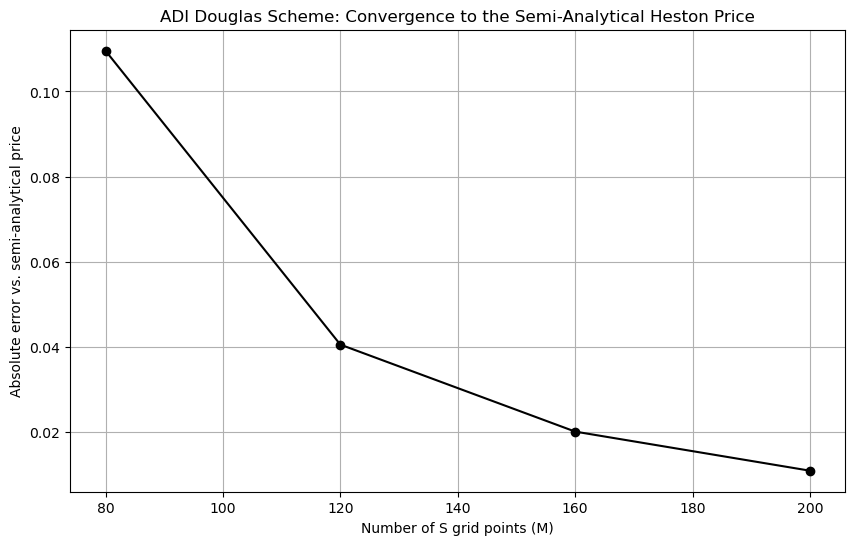

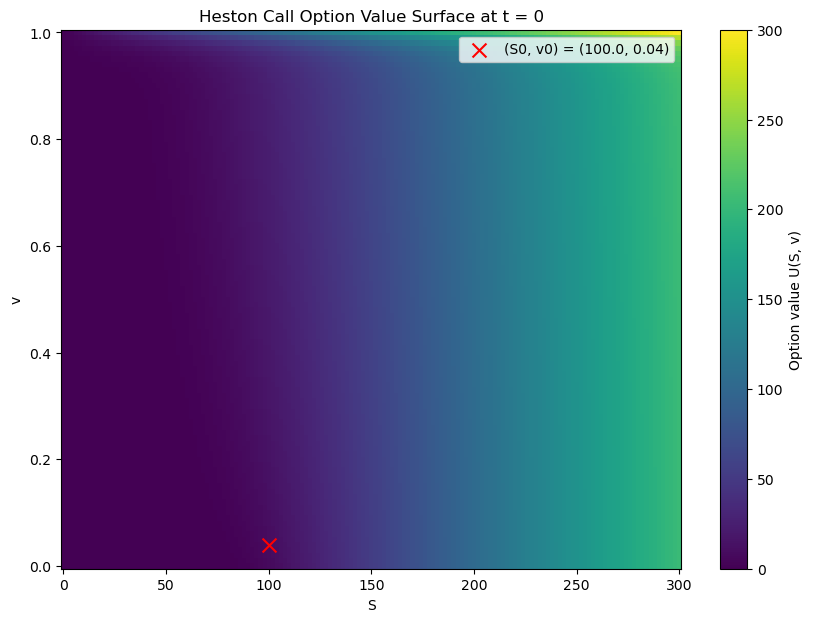

In [5]:
# Convergence plot: grid resolution vs. absolute error
Ms = [g[0] for g in results]
errs = [g[4] for g in results]

plt.figure(figsize=(10, 6))
plt.plot(Ms, errs, marker='o', color='black')
plt.xlabel('Number of S grid points (M)')
plt.ylabel('Absolute error vs. semi-analytical price')
plt.title('ADI Douglas Scheme: Convergence to the Semi-Analytical Heston Price')
plt.grid(True)
plt.savefig('heston_adi_convergence.png', dpi=110, bbox_inches='tight')
plt.show()

# Option value surface U(S, v) at t=0 (tau=T)
S_mask = S_grid <= 3*K
plt.figure(figsize=(10, 7))
im = plt.pcolormesh(S_grid[S_mask], v_grid, U_final[S_mask, :].T, shading='auto', cmap='viridis')
plt.colorbar(im, label='Option value U(S, v)')
plt.scatter([S0], [v0], color='red', marker='x', s=100, label=f'(S0, v0) = ({S0}, {v0})')
plt.xlabel('S')
plt.ylabel('v')
plt.title('Heston Call Option Value Surface at t = 0')
plt.legend()
plt.savefig('heston_value_surface.png', dpi=110, bbox_inches='tight')
plt.show()